In [1]:
import sys
print(sys.executable)


/Users/akhil/Desktop/bank-churn-prediction/venv/bin/python


In [2]:
import pandas as pd
print("Notebook is connected correctly")

Notebook is connected correctly


In [3]:
import pandas as pd

df = pd.read_csv("../data/European_Bank.csv")
df.head()


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/European_Bank.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (10000, 14)
   Year  CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure  \
0  2025    15634602  Hargrave          619    France  Female   42       2   
1  2025    15647311      Hill          608     Spain  Female   41       1   
2  2025    15619304      Onio          502    France  Female   42       8   
3  2025    15701354      Boni          699    France  Female   39       1   
4  2025    15737888  Mitchell          850     Spain  Female   43       2   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              1          1               1        101348.88   
1   83807.86              1          0               1        112542.58   
2  159660.80              3          1               0        113931.57   
3       0.00              2          0               0         93826.63   
4  125510.82              1          1               1         79084.10   

   Exited  
0       1  
1       0  
2       1  
3       0  
4      

In [5]:
print(df.columns.tolist())
print()
print(df.dtypes)

['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Year                 int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [6]:
print(df.isnull().sum())

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
print(df['Exited'].value_counts())
print()
print(df['Exited'].value_counts(normalize=True).round(4) * 100)

Exited
0    7963
1    2037
Name: count, dtype: int64

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [9]:
print("Geography:", df['Geography'].unique())
print("Gender:", df['Gender'].unique())
print("HasCrCard:", df['HasCrCard'].unique())
print("IsActiveMember:", df['IsActiveMember'].unique())
print("Year:", df['Year'].unique())

Geography: ['France' 'Spain' 'Germany']
Gender: ['Female' 'Male']
HasCrCard: [1 0]
IsActiveMember: [1 0]
Year: [2025]


In [10]:
print(df[['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']].describe())

        CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

       EstimatedSalary  
count     10000.000000  
mean     100090.239881  
std       57510.492818  
min          11.580000  
25%       51002.110000  
50%      100193.915000  
75%      149388.247500  
max      199992.480000  


In [11]:
assert (df['CreditScore'] >= 300).all() and (df['CreditScore'] <= 850).all(), "CreditScore out of realistic range!"
assert (df['Age'] >= 18).all(), "Age below 18 found!"
assert (df['Balance'] >= 0).all(), "Negative balance found!"
assert (df['EstimatedSalary'] >= 0).all(), "Negative salary found!"
assert df['CustomerId'].nunique() == len(df), "Duplicate CustomerIds found!"
print("✅ All business-rule checks passed")

✅ All business-rule checks passed


In [12]:
df.to_pickle('../data/validated_data.pkl')
print("Validated data saved:", df.shape)

Validated data saved: (10000, 14)


In [13]:
import os
print(os.path.exists('../data/validated_data.pkl'))

True


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_pickle('../data/validated_data.pkl')
os.makedirs('../report', exist_ok=True)
sns.set_style('whitegrid')
print("Loaded:", df.shape)

Loaded: (10000, 14)


Geography
Germany    32.44
Spain      16.67
France     16.15
Name: Exited, dtype: float64


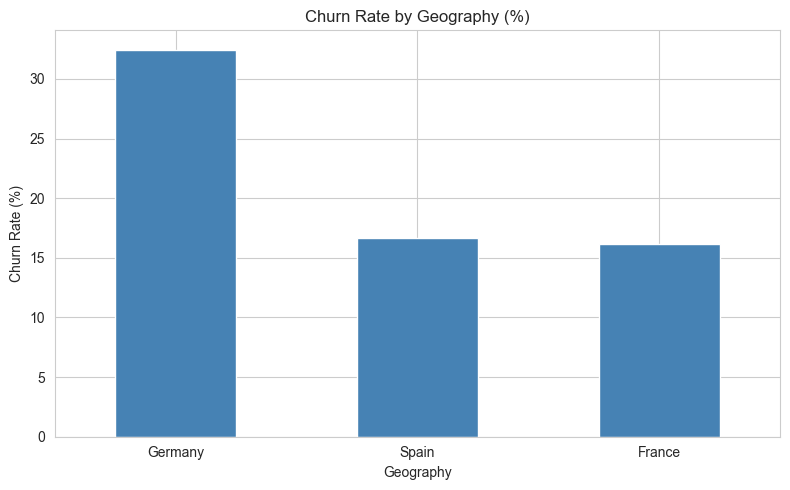

In [15]:
churn_by_geo = df.groupby('Geography')['Exited'].mean().sort_values(ascending=False) * 100
print(churn_by_geo.round(2))

plt.figure(figsize=(8,5))
churn_by_geo.plot(kind='bar', color='steelblue')
plt.title('Churn Rate by Geography (%)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../report/01_churn_by_geography.png', dpi=150)
plt.show()

In [16]:
print(os.path.exists('../report/01_churn_by_geography.png'))

True


Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64


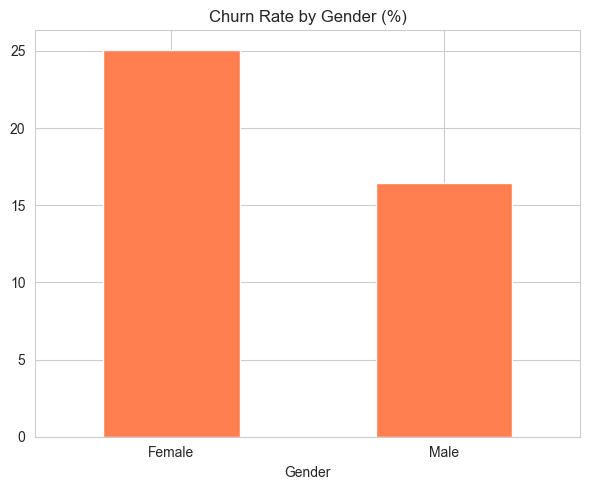

In [17]:
churn_by_gender = df.groupby('Gender')['Exited'].mean().sort_values(ascending=False) * 100
print(churn_by_gender.round(2))

plt.figure(figsize=(6,5))
churn_by_gender.plot(kind='bar', color='coral')
plt.title('Churn Rate by Gender (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../report/02_churn_by_gender.png', dpi=150)
plt.show()

NumOfProducts
4    100.00
3     82.71
1     27.71
2      7.58
Name: Exited, dtype: float64


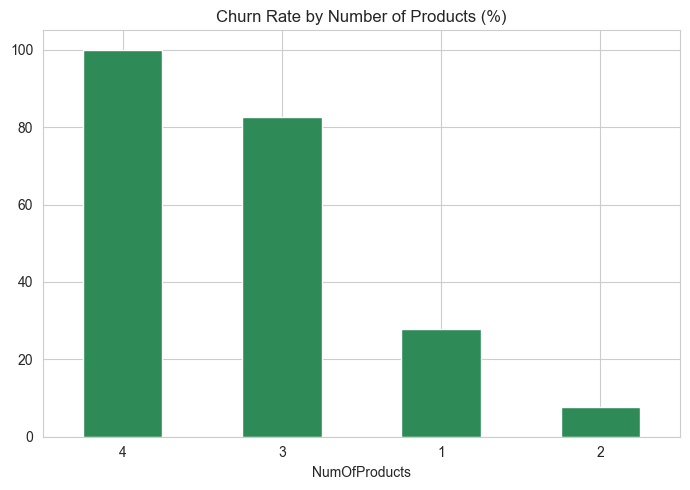

In [18]:
churn_by_products = df.groupby('NumOfProducts')['Exited'].mean().sort_values(ascending=False) * 100
print(churn_by_products.round(2))

plt.figure(figsize=(7,5))
churn_by_products.plot(kind='bar', color='seagreen')
plt.title('Churn Rate by Number of Products (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../report/03_churn_by_products.png', dpi=150)
plt.show()

IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64


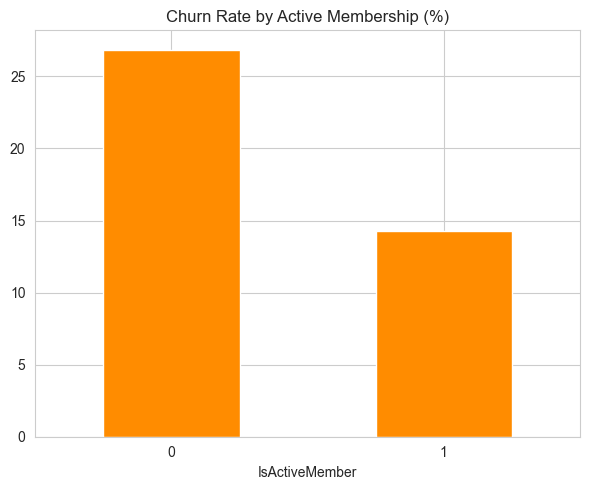

In [19]:
churn_by_active = df.groupby('IsActiveMember')['Exited'].mean().sort_values(ascending=False) * 100
print(churn_by_active.round(2))

plt.figure(figsize=(6,5))
churn_by_active.plot(kind='bar', color='darkorange')
plt.title('Churn Rate by Active Membership (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../report/04_churn_by_active.png', dpi=150)
plt.show()

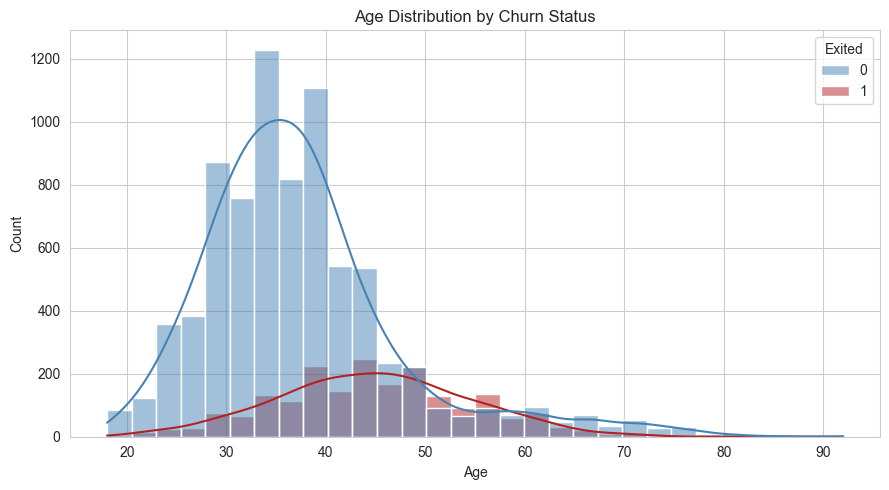

In [20]:
plt.figure(figsize=(9,5))
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True, palette=['steelblue','firebrick'])
plt.title('Age Distribution by Churn Status')
plt.tight_layout()
plt.savefig('../report/05_age_distribution.png', dpi=150)
plt.show()

In [21]:
with open('../report/eda_findings.txt', 'w') as f:
    f.write("EDA FINDINGS\n\n")
    f.write(f"1. Churn rate by Geography (chart: 01_churn_by_geography.png):\n{churn_by_geo.round(2).to_string()}\n\n")
    f.write(f"2. Churn rate by Gender (chart: 02_churn_by_gender.png):\n{churn_by_gender.round(2).to_string()}\n\n")
    f.write(f"3. Churn rate by NumOfProducts (chart: 03_churn_by_products.png):\n{churn_by_products.round(2).to_string()}\n\n")
    f.write(f"4. Churn rate by Active Membership (chart: 04_churn_by_active.png):\n{churn_by_active.round(2).to_string()}\n\n")
    f.write(f"5. Age distribution differs between churned/retained customers (chart: 05_age_distribution.png)\n\n")

with open('../report/eda_findings.txt') as f:
    print(f.read())

EDA FINDINGS

1. Churn rate by Geography (chart: 01_churn_by_geography.png):
Geography
Germany    32.44
Spain      16.67
France     16.15

2. Churn rate by Gender (chart: 02_churn_by_gender.png):
Gender
Female    25.07
Male      16.46

3. Churn rate by NumOfProducts (chart: 03_churn_by_products.png):
NumOfProducts
4    100.00
3     82.71
1     27.71
2      7.58

4. Churn rate by Active Membership (chart: 04_churn_by_active.png):
IsActiveMember
0    26.85
1    14.27

5. Age distribution differs between churned/retained customers (chart: 05_age_distribution.png)




In [22]:
import glob
chart_files = sorted(glob.glob('../report/*.png'))
print(f"Total charts saved: {len(chart_files)}")
for f in chart_files:
    print(" -", f)

Total charts saved: 8
 - ../report/01_churn_by_geography.png
 - ../report/02_churn_by_gender.png
 - ../report/03_churn_by_products.png
 - ../report/04_churn_by_active.png
 - ../report/05_age_distribution.png
 - ../report/06_feature_importance.png
 - ../report/07_shap_summary.png
 - ../report/08_shap_dependence_top_feature.png


In [23]:
print(df['NumOfProducts'].value_counts().sort_index())

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


In [24]:
with open('../report/eda_findings.txt', 'w') as f:
    f.write("EDA FINDINGS\n\n")
    f.write("1. Churn rate by Geography (chart: 01_churn_by_geography.png):\n")
    f.write("Germany: 32.44%, Spain: 16.67%, France: 16.15%. Germany's churn rate is roughly double that of the other two countries.\n\n")

    f.write("2. Churn rate by Gender (chart: 02_churn_by_gender.png):\n")
    f.write("Female: 25.07%, Male: 16.46%. Female customers churn at roughly 1.5x the rate of male customers.\n\n")

    f.write("3. Churn rate by NumOfProducts (chart: 03_churn_by_products.png):\n")
    f.write("1 product: 27.71% (n=5,084), 2 products: 7.58% (n=4,590), 3 products: 82.71% (n=266), 4 products: 100.00% (n=60). ")
    f.write("2 products is the safest position; risk climbs sharply on either side, with 3-4 product customers representing a small but extremely high-risk segment.\n\n")

    f.write("4. Churn rate by Active Membership (chart: 04_churn_by_active.png):\n")
    f.write("Inactive members: 26.85%, Active members: 14.27%. Inactive members churn at roughly 1.9x the rate of active members.\n\n")

    f.write("5. Age distribution by churn status (chart: 05_age_distribution.png):\n")
    f.write("Retained customers are concentrated around ages 30-40 (peak ~35). Churned customers show a flatter, wider distribution peaking later around ages 45-50, ")
    f.write("with meaningfully more presence in the 50-65 range - churned customers skew noticeably older than retained customers.\n\n")

with open('../report/eda_findings.txt') as f:
    print(f.read())

EDA FINDINGS

1. Churn rate by Geography (chart: 01_churn_by_geography.png):
Germany: 32.44%, Spain: 16.67%, France: 16.15%. Germany's churn rate is roughly double that of the other two countries.

2. Churn rate by Gender (chart: 02_churn_by_gender.png):
Female: 25.07%, Male: 16.46%. Female customers churn at roughly 1.5x the rate of male customers.

3. Churn rate by NumOfProducts (chart: 03_churn_by_products.png):
1 product: 27.71% (n=5,084), 2 products: 7.58% (n=4,590), 3 products: 82.71% (n=266), 4 products: 100.00% (n=60). 2 products is the safest position; risk climbs sharply on either side, with 3-4 product customers representing a small but extremely high-risk segment.

4. Churn rate by Active Membership (chart: 04_churn_by_active.png):
Inactive members: 26.85%, Active members: 14.27%. Inactive members churn at roughly 1.9x the rate of active members.

5. Age distribution by churn status (chart: 05_age_distribution.png):
Retained customers are concentrated around ages 30-40 (pea

In [25]:
import glob
chart_files = sorted(glob.glob('../report/*.png'))
print(f"Total charts saved: {len(chart_files)}")
for f in chart_files:
    print(" -", f)

Total charts saved: 8
 - ../report/01_churn_by_geography.png
 - ../report/02_churn_by_gender.png
 - ../report/03_churn_by_products.png
 - ../report/04_churn_by_active.png
 - ../report/05_age_distribution.png
 - ../report/06_feature_importance.png
 - ../report/07_shap_summary.png
 - ../report/08_shap_dependence_top_feature.png


In [26]:
df = pd.read_pickle('../data/validated_data.pkl')
df_model = df.drop(columns=['CustomerId', 'Surname', 'Year'])
print(df_model.shape)
print(df_model.columns.tolist())

(10000, 11)
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [27]:
print("Any Year column left?", 'Year' in df_model.columns)
print("Any CustomerId column left?", 'CustomerId' in df_model.columns)

Any Year column left? False
Any CustomerId column left? False


In [28]:
df_model = pd.get_dummies(df_model, columns=['Geography', 'Gender'], drop_first=True)
print(df_model.columns.tolist())
print(df_model.shape)

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
(10000, 12)


In [29]:
print(df_model[['Geography_Germany','Geography_Spain','Gender_Male']].sum())
print()
print("Cross-check — actual France count:", (df['Geography'] == 'France').sum())
print("Actual Germany count:", (df['Geography'] == 'Germany').sum())
print("Germany count from new column:", df_model['Geography_Germany'].sum())
print()
print("Actual Spain count:", (df['Geography'] == 'Spain').sum())
print("Spain count from new column:", df_model['Geography_Spain'].sum())
print()
print("Actual Male count:", (df['Gender'] == 'Male').sum())
print("Male count from new column:", df_model['Gender_Male'].sum())

Geography_Germany    2509
Geography_Spain      2477
Gender_Male          5457
dtype: int64

Cross-check — actual France count: 5014
Actual Germany count: 2509
Germany count from new column: 2509

Actual Spain count: 2477
Spain count from new column: 2477

Actual Male count: 5457
Male count from new column: 5457


In [30]:
france_count = (df['Geography'] == 'France').sum()
implied_france = ((df_model['Geography_Germany'] == 0) & (df_model['Geography_Spain'] == 0)).sum()
print("Actual France count:", france_count)
print("Implied France count (both dummy columns = 0):", implied_france)

Actual France count: 5014
Implied France count (both dummy columns = 0): 5014


In [31]:
print("Nulls:", df_model.isnull().sum().sum(), "should be 0")
print("Shape:", df_model.shape)
print()
print(df_model.dtypes)

Nulls: 0 should be 0
Shape: (10000, 12)

CreditScore            int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Geography_Germany       bool
Geography_Spain         bool
Gender_Male             bool
dtype: object


In [32]:
df_model.to_pickle('../data/preprocessed_data.pkl')
print("Preprocessing checkpoint saved:", df_model.shape)

Preprocessing checkpoint saved: (10000, 12)


In [33]:
import pandas as pd
import numpy as np


In [34]:
df_model = pd.read_pickle('../data/preprocessed_data.pkl')

# Balance-to-Salary ratio
df_model['BalanceSalaryRatio'] = df_model['Balance'] / (df_model['EstimatedSalary'] + 1)

# Product density indicator
df_model['ProductDensity'] = df_model['NumOfProducts'] / (df_model['Tenure'] + 1)

# Engagement-product interaction
df_model['EngagementProductInteraction'] = df_model['IsActiveMember'] * df_model['NumOfProducts']

# Age-tenure interaction
df_model['AgeTenureInteraction'] = df_model['Age'] * df_model['Tenure']

print(df_model[['BalanceSalaryRatio','ProductDensity','EngagementProductInteraction','AgeTenureInteraction']].describe())

       BalanceSalaryRatio  ProductDensity  EngagementProductInteraction  \
count        10000.000000    10000.000000                  10000.000000   
mean             3.790150        0.367173                      0.791000   
std            100.055758        0.337760                      0.870169   
min              0.000000        0.090909                      0.000000   
25%              0.000000        0.166667                      0.000000   
50%              0.746998        0.250000                      1.000000   
75%              1.514002        0.500000                      2.000000   
max           9770.883148        3.000000                      4.000000   

       AgeTenureInteraction  
count          10000.000000  
mean             194.804000  
std              127.939996  
min                0.000000  
25%               90.000000  
50%              180.000000  
75%              280.000000  
max              880.000000  


In [35]:
numeric_check = df_model.select_dtypes(include=[np.number])
print("Any infinite values:", np.isinf(numeric_check).sum().sum())
print("Any nulls:", df_model.isnull().sum().sum())
print("Total rows:", len(df_model))

Any infinite values: 0
Any nulls: 0
Total rows: 10000


In [36]:
print(df_model[df_model['EstimatedSalary'] == -1])  # would trigger inf if this existed
print((df_model['Tenure'] == -1).sum())

Empty DataFrame
Columns: [CreditScore, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited, Geography_Germany, Geography_Spain, Gender_Male, BalanceSalaryRatio, ProductDensity, EngagementProductInteraction, AgeTenureInteraction]
Index: []
0


In [37]:
sample = df_model.iloc[0]

manual_ratio = sample['Balance'] / (sample['EstimatedSalary'] + 1)
manual_density = sample['NumOfProducts'] / (sample['Tenure'] + 1)
manual_engagement = sample['IsActiveMember'] * sample['NumOfProducts']
manual_age_tenure = sample['Age'] * sample['Tenure']

print("Row 0 raw values:")
print(f"  Balance: {sample['Balance']}, EstimatedSalary: {sample['EstimatedSalary']}")
print(f"  NumOfProducts: {sample['NumOfProducts']}, Tenure: {sample['Tenure']}")
print(f"  IsActiveMember: {sample['IsActiveMember']}, Age: {sample['Age']}")
print()
print("BalanceSalaryRatio — stored:", sample['BalanceSalaryRatio'], "| manually recomputed:", manual_ratio)
print("Match:", round(sample['BalanceSalaryRatio'], 6) == round(manual_ratio, 6))
print()
print("ProductDensity — stored:", sample['ProductDensity'], "| manually recomputed:", manual_density)
print("Match:", round(sample['ProductDensity'], 6) == round(manual_density, 6))
print()
print("EngagementProductInteraction — stored:", sample['EngagementProductInteraction'], "| manually recomputed:", manual_engagement)
print("Match:", sample['EngagementProductInteraction'] == manual_engagement)
print()
print("AgeTenureInteraction — stored:", sample['AgeTenureInteraction'], "| manually recomputed:", manual_age_tenure)
print("Match:", sample['AgeTenureInteraction'] == manual_age_tenure)

Row 0 raw values:
  Balance: 0.0, EstimatedSalary: 101348.88
  NumOfProducts: 1, Tenure: 2
  IsActiveMember: 1, Age: 42

BalanceSalaryRatio — stored: 0.0 | manually recomputed: 0.0
Match: True

ProductDensity — stored: 0.3333333333333333 | manually recomputed: 0.3333333333333333
Match: True

EngagementProductInteraction — stored: 1 | manually recomputed: 1
Match: True

AgeTenureInteraction — stored: 84 | manually recomputed: 84
Match: True


In [38]:
sample2 = df_model.iloc[100]
manual_ratio2 = sample2['Balance'] / (sample2['EstimatedSalary'] + 1)
print("Row 100 BalanceSalaryRatio match:", round(sample2['BalanceSalaryRatio'], 6) == round(manual_ratio2, 6))

Row 100 BalanceSalaryRatio match: True


In [39]:
df_model.to_pickle('../data/featured_data.pkl')
print("Feature engineering complete:", df_model.shape)

Feature engineering complete: (10000, 16)


In [40]:
import os
print(os.path.exists('../data/featured_data.pkl'))

True


In [41]:
print(df_model.columns.tolist())

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'BalanceSalaryRatio', 'ProductDensity', 'EngagementProductInteraction', 'AgeTenureInteraction']


In [42]:
from sklearn.model_selection import train_test_split

df_model = pd.read_pickle('../data/featured_data.pkl')

X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

X shape: (10000, 15)
y shape: (10000,)

Train shape: (8000, 15)
Test shape: (2000, 15)


In [43]:
print("Overall churn rate:", round(y.mean(), 4))
print("Train churn rate:", round(y_train.mean(), 4))
print("Test churn rate:", round(y_test.mean(), 4))
print()
print("Train churn count:", y_train.sum(), "out of", len(y_train))
print("Test churn count:", y_test.sum(), "out of", len(y_test))

# Extra verification
print("Expected train churners (~80% of 2037):", round(2037 * 0.8))
print("Expected test churners (~20% of 2037):", round(2037 * 0.2))


Overall churn rate: 0.2037
Train churn rate: 0.2037
Test churn rate: 0.2035

Train churn count: 1630 out of 8000
Test churn count: 407 out of 2000
Expected train churners (~80% of 2037): 1630
Expected test churners (~20% of 2037): 407


In [44]:
print("Train + Test churn count:", y_train.sum() + y_test.sum(), "should equal", y.sum())
print("Train + Test total rows:", len(y_train) + len(y_test), "should equal", len(y))

Train + Test churn count: 2037 should equal 2037
Train + Test total rows: 10000 should equal 10000


In [45]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary',
                 'BalanceSalaryRatio', 'ProductDensity', 'AgeTenureInteraction']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling applied")
print()
print("Train scaled stats:")
print(X_train_scaled[numeric_cols].describe().round(2))

Scaling applied

Train scaled stats:
       CreditScore      Age   Tenure  Balance  EstimatedSalary  \
count      8000.00  8000.00  8000.00  8000.00          8000.00   
mean         -0.00     0.00    -0.00     0.00            -0.00   
std           1.00     1.00     1.00     1.00             1.00   
min          -3.11    -1.99    -1.73    -1.23            -1.74   
25%          -0.69    -0.66    -0.70    -1.23            -0.86   
50%           0.01    -0.18    -0.01     0.33            -0.00   
75%           0.69     0.48     1.03     0.82             0.85   
max           2.06     5.04     1.72     2.60             1.75   

       BalanceSalaryRatio  ProductDensity  AgeTenureInteraction  
count             8000.00         8000.00               8000.00  
mean                 0.00            0.00                 -0.00  
std                  1.00            1.00                  1.00  
min                 -0.04           -0.82                 -1.52  
25%                 -0.04           -0

In [46]:
print("Train mean (should be ~0):")
print(X_train_scaled[numeric_cols].mean().round(4))
print()
print("Train std (should be ~1):")
print(X_train_scaled[numeric_cols].std().round(4))

Train mean (should be ~0):
CreditScore            -0.0
Age                     0.0
Tenure                 -0.0
Balance                 0.0
EstimatedSalary        -0.0
BalanceSalaryRatio      0.0
ProductDensity          0.0
AgeTenureInteraction   -0.0
dtype: float64

Train std (should be ~1):
CreditScore             1.0001
Age                     1.0001
Tenure                  1.0001
Balance                 1.0001
EstimatedSalary         1.0001
BalanceSalaryRatio      1.0001
ProductDensity          1.0001
AgeTenureInteraction    1.0001
dtype: float64


In [47]:
print("Test mean (won't be exactly 0, that's normal):")
print(X_test_scaled[numeric_cols].mean().round(4))

Test mean (won't be exactly 0, that's normal):
CreditScore            -0.0116
Age                    -0.0118
Tenure                 -0.0066
Balance                 0.0084
EstimatedSalary         0.0313
BalanceSalaryRatio     -0.0144
ProductDensity          0.0198
AgeTenureInteraction   -0.0187
dtype: float64


In [48]:
import joblib

joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(X_train_scaled.columns.tolist(), '../models/model_columns.pkl')
joblib.dump(numeric_cols, '../models/numeric_cols.pkl')

print("Scaler saved")
print("Model columns saved:", len(X_train_scaled.columns.tolist()), "columns")
print("Numeric columns saved:", numeric_cols)

Scaler saved
Model columns saved: 15 columns
Numeric columns saved: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'BalanceSalaryRatio', 'ProductDensity', 'AgeTenureInteraction']


In [49]:
import os
print(os.path.exists('../models/scaler.pkl'))
print(os.path.exists('../models/model_columns.pkl'))
print(os.path.exists('../models/numeric_cols.pkl'))

True
True
True


In [50]:
X_train_scaled.to_pickle('../data/X_train_scaled.pkl')
X_test_scaled.to_pickle('../data/X_test_scaled.pkl')
y_train.to_pickle('../data/y_train.pkl')
y_test.to_pickle('../data/y_test.pkl')
print("Train/test split checkpoint saved")

Train/test split checkpoint saved


In [51]:
saved_columns = joblib.load('../models/model_columns.pkl')
print("Saved columns match X_train_scaled:", saved_columns == X_train_scaled.columns.tolist())
print("Total feature columns:", len(saved_columns))

Saved columns match X_train_scaled: True
Total feature columns: 15


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 3))
print("Precision:", round(precision_score(y_test, y_pred_log), 3))
print("Recall:", round(recall_score(y_test, y_pred_log), 3))
print("F1:", round(f1_score(y_test, y_pred_log), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_log), 3))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.807
Precision: 0.578
Recall: 0.192
F1: 0.288
ROC-AUC: 0.774


In [53]:
print("Predicted churn count:", y_pred_log.sum(), "out of", len(y_pred_log))
print("Actual churn count in test set:", y_test.sum(), "out of", len(y_test))

Predicted churn count: 135 out of 2000
Actual churn count in test set: 407 out of 2000


In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:")
print(cm)
print()
print(f"True Negatives (correctly predicted 'stayed'): {cm[0][0]}")
print(f"False Positives (predicted churn, actually stayed): {cm[0][1]}")
print(f"False Negatives (predicted stayed, actually churned): {cm[1][0]}")
print(f"True Positives (correctly predicted 'churned'): {cm[1][1]}")

Confusion Matrix:
[[1536   57]
 [ 329   78]]

True Negatives (correctly predicted 'stayed'): 1536
False Positives (predicted churn, actually stayed): 57
False Negatives (predicted stayed, actually churned): 329
True Positives (correctly predicted 'churned'): 78


In [55]:
total = cm[0][0] + cm[0][1] + cm[1][0] + cm[1][1]
print("Sum of all 4 cells:", total, "should equal 2000")

Sum of all 4 cells: 2000 should equal 2000


In [56]:
print("True Positives + False Negatives:", cm[1][1] + cm[1][0], "should equal", y_test.sum())

True Positives + False Negatives: 407 should equal 407


In [57]:
false_negative_rate = cm[1][0] / (cm[1][0] + cm[1][1])
print(f"Of all customers who actually churned, the model MISSED {cm[1][0]} of them ({false_negative_rate*100:.1f}%)")

Of all customers who actually churned, the model MISSED 329 of them (80.8%)


In [58]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
y_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

print("DECISION TREE RESULTS")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 3))
print("Precision:", round(precision_score(y_test, y_pred_dt), 3))
print("Recall:", round(recall_score(y_test, y_pred_dt), 3))
print("F1:", round(f1_score(y_test, y_pred_dt), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_dt), 3))

DECISION TREE RESULTS
Accuracy: 0.86
Precision: 0.782
Recall: 0.432
F1: 0.557
ROC-AUC: 0.839


In [59]:
print("Predicted churn count:", y_pred_dt.sum(), "out of", len(y_pred_dt))
print("Actual churn count in test set:", y_test.sum(), "out of", len(y_test))

Predicted churn count: 225 out of 2000
Actual churn count in test set: 407 out of 2000


In [60]:
train_acc_dt = dt_model.score(X_train_scaled, y_train)
test_acc_dt = dt_model.score(X_test_scaled, y_test)
gap = train_acc_dt - test_acc_dt

print(f"Train accuracy: {train_acc_dt:.3f}")
print(f"Test accuracy: {test_acc_dt:.3f}")
print(f"Gap: {gap:.3f}")

Train accuracy: 0.869
Test accuracy: 0.860
Gap: 0.009


In [61]:
dt_model_v2 = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model_v2.fit(X_train_scaled, y_train)

train_acc_v2 = dt_model_v2.score(X_train_scaled, y_train)
test_acc_v2 = dt_model_v2.score(X_test_scaled, y_test)
print(f"With max_depth=4 — Train: {train_acc_v2:.3f}, Test: {test_acc_v2:.3f}, Gap: {(train_acc_v2 - test_acc_v2):.3f}")

With max_depth=4 — Train: 0.851, Test: 0.852, Gap: -0.000


In [62]:
importance_check = pd.Series(dt_model.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
print("Top 5 features this Decision Tree relies on:")
print(importance_check.head(5).round(4))

Top 5 features this Decision Tree relies on:
Age                             0.3857
NumOfProducts                   0.2507
EngagementProductInteraction    0.1692
Balance                         0.0656
Geography_Germany               0.0547
dtype: float64


In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("RANDOM FOREST RESULTS")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))
print("Recall:", round(recall_score(y_test, y_pred_rf), 3))
print("F1:", round(f1_score(y_test, y_pred_rf), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 3))

RANDOM FOREST RESULTS
Accuracy: 0.868
Precision: 0.852
Recall: 0.425
F1: 0.567
ROC-AUC: 0.865


In [64]:
train_acc_rf = rf_model.score(X_train_scaled, y_train)
test_acc_rf = rf_model.score(X_test_scaled, y_test)
gap_rf = train_acc_rf - test_acc_rf

print(f"Train accuracy: {train_acc_rf:.3f}")
print(f"Test accuracy: {test_acc_rf:.3f}")
print(f"Gap: {gap_rf:.3f}")
print()
print("Predicted churn count:", y_pred_rf.sum(), "out of", len(y_pred_rf))
print("Actual churn count in test set:", y_test.sum(), "out of", len(y_test))

Train accuracy: 0.880
Test accuracy: 0.868
Gap: 0.012

Predicted churn count: 203 out of 2000
Actual churn count in test set: 407 out of 2000


In [65]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)
print()
print(f"True Negatives: {cm_rf[0][0]}")
print(f"False Positives: {cm_rf[0][1]}")
print(f"False Negatives: {cm_rf[1][0]}")
print(f"True Positives: {cm_rf[1][1]}")
print()
print("Sum check:", cm_rf.sum(), "should equal 2000")
print("TP + FN check:", cm_rf[1][1] + cm_rf[1][0], "should equal 407")

Confusion Matrix:
[[1563   30]
 [ 234  173]]

True Negatives: 1563
False Positives: 30
False Negatives: 234
True Positives: 173

Sum check: 2000 should equal 2000
TP + FN check: 407 should equal 407


In [66]:
importance_rf = pd.Series(rf_model.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
print("Top 5 features Random Forest relies on:")
print(importance_rf.head(5).round(4))

Top 5 features Random Forest relies on:
Age                             0.2999
NumOfProducts                   0.2033
EngagementProductInteraction    0.0925
AgeTenureInteraction            0.0603
Balance                         0.0545
dtype: float64


In [67]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)
y_proba_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

print("GRADIENT BOOSTING RESULTS")
print("Accuracy:", round(accuracy_score(y_test, y_pred_gb), 3))
print("Precision:", round(precision_score(y_test, y_pred_gb), 3))
print("Recall:", round(recall_score(y_test, y_pred_gb), 3))
print("F1:", round(f1_score(y_test, y_pred_gb), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_gb), 3))

GRADIENT BOOSTING RESULTS
Accuracy: 0.862
Precision: 0.739
Recall: 0.494
F1: 0.592
ROC-AUC: 0.862


In [68]:
train_acc_gb = gb_model.score(X_train_scaled, y_train)
test_acc_gb = gb_model.score(X_test_scaled, y_test)
print(f"Train accuracy: {train_acc_gb:.3f}")
print(f"Test accuracy: {test_acc_gb:.3f}")
print(f"Gap: {(train_acc_gb - test_acc_gb):.3f}")

Train accuracy: 0.904
Test accuracy: 0.862
Gap: 0.043


In [69]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
print("Confusion Matrix:")
print(cm_gb)
print()
print(f"True Negatives: {cm_gb[0][0]}, False Positives: {cm_gb[0][1]}")
print(f"False Negatives: {cm_gb[1][0]}, True Positives: {cm_gb[1][1]}")
print()
print("Sum check:", cm_gb.sum(), "should equal 2000")
print("TP + FN check:", cm_gb[1][1] + cm_gb[1][0], "should equal 407")

Confusion Matrix:
[[1522   71]
 [ 206  201]]

True Negatives: 1522, False Positives: 71
False Negatives: 206, True Positives: 201

Sum check: 2000 should equal 2000
TP + FN check: 407 should equal 407


In [70]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("XGBOOST RESULTS")
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 3))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 3))
print("Recall:", round(recall_score(y_test, y_pred_xgb), 3))
print("F1:", round(f1_score(y_test, y_pred_xgb), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_xgb), 3))

XGBOOST RESULTS
Accuracy: 0.869
Precision: 0.779
Recall: 0.494
F1: 0.605
ROC-AUC: 0.861


In [71]:
train_acc_xgb = xgb_model.score(X_train_scaled, y_train)
test_acc_xgb = xgb_model.score(X_test_scaled, y_test)
print(f"Train accuracy: {train_acc_xgb:.3f}")
print(f"Test accuracy: {test_acc_xgb:.3f}")
print(f"Gap: {(train_acc_xgb - test_acc_xgb):.3f}")

Train accuracy: 0.895
Test accuracy: 0.869
Gap: 0.026


In [72]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:")
print(cm_xgb)
print()
print(f"True Negatives: {cm_xgb[0][0]}, False Positives: {cm_xgb[0][1]}")
print(f"False Negatives: {cm_xgb[1][0]}, True Positives: {cm_xgb[1][1]}")
print()
print("Sum check:", cm_xgb.sum(), "should equal 2000")
print("TP + FN check:", cm_xgb[1][1] + cm_xgb[1][0], "should equal 407")

Confusion Matrix:
[[1536   57]
 [ 206  201]]

True Negatives: 1536, False Positives: 57
False Negatives: 206, True Positives: 201

Sum check: 2000 should equal 2000
TP + FN check: 407 should equal 407


In [73]:
importance_xgb = pd.Series(xgb_model.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
print("Top 5 features XGBoost relies on:")
print(importance_xgb.head(5).round(4))

Top 5 features XGBoost relies on:
NumOfProducts                   0.2178
IsActiveMember                  0.1842
Age                             0.1561
Geography_Germany               0.0960
EngagementProductInteraction    0.0646
dtype: float32


In [74]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_dt),
                 accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_gb),
                 accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_dt),
                  precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_gb),
                  precision_score(y_test, y_pred_xgb)],
    'Recall': [recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_dt),
               recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_gb),
               recall_score(y_test, y_pred_xgb)],
    'F1': [f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_dt),
           f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_gb),
           f1_score(y_test, y_pred_xgb)],
    'ROC_AUC': [roc_auc_score(y_test, y_proba_log), roc_auc_score(y_test, y_proba_dt),
                roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_gb),
                roc_auc_score(y_test, y_proba_xgb)]
}).round(3)

results_by_auc = results.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
print("Sorted by ROC-AUC:")
print(results_by_auc)
print()
results_by_f1 = results.sort_values('F1', ascending=False).reset_index(drop=True)
print("Sorted by F1:")
print(results_by_f1)

results.to_csv('../report/model_comparison.csv', index=False)

Sorted by ROC-AUC:
                 Model  Accuracy  Precision  Recall     F1  ROC_AUC
0        Random Forest     0.868      0.852   0.425  0.567    0.865
1    Gradient Boosting     0.862      0.739   0.494  0.592    0.862
2              XGBoost     0.868      0.779   0.494  0.605    0.861
3        Decision Tree     0.860      0.782   0.432  0.557    0.839
4  Logistic Regression     0.807      0.578   0.192  0.288    0.774

Sorted by F1:
                 Model  Accuracy  Precision  Recall     F1  ROC_AUC
0              XGBoost     0.868      0.779   0.494  0.605    0.861
1    Gradient Boosting     0.862      0.739   0.494  0.592    0.862
2        Random Forest     0.868      0.852   0.425  0.567    0.865
3        Decision Tree     0.860      0.782   0.432  0.557    0.839
4  Logistic Regression     0.807      0.578   0.192  0.288    0.774


In [75]:
import os
print(os.path.exists('../report/model_comparison.csv'))

True


In [76]:
import joblib

# Given your results: XGBoost has the best F1 (0.605) and ties for best Recall (0.494),
# catching the most actual churners (201) while keeping false alarms low.
# Random Forest has marginally higher ROC-AUC (0.865 vs 0.861) and the best Precision (0.852).
# XGBoost is the recommended choice given the project's emphasis on identifying at-risk
# customers for proactive retention - but you can substitute rf_model below if you prefer
# to prioritize precision instead.

best_model_name = "XGBoost"
final_model = xgb_model

joblib.dump(final_model, '../models/churn_model.pkl')
print(f"{best_model_name} saved as the final model")

# Verify the save worked and the file is a reasonable size
import os
file_size_kb = os.path.getsize('../models/churn_model.pkl') / 1024
print(f"File exists: {os.path.exists('../models/churn_model.pkl')}")
print(f"File size: {file_size_kb:.1f} KB")

XGBoost saved as the final model
File exists: True
File size: 306.4 KB


In [77]:
reloaded_model = joblib.load('../models/churn_model.pkl')
reloaded_predictions = reloaded_model.predict(X_test_scaled)

print("Reloaded model predictions match original:", (reloaded_predictions == y_pred_xgb).all())

Reloaded model predictions match original: True


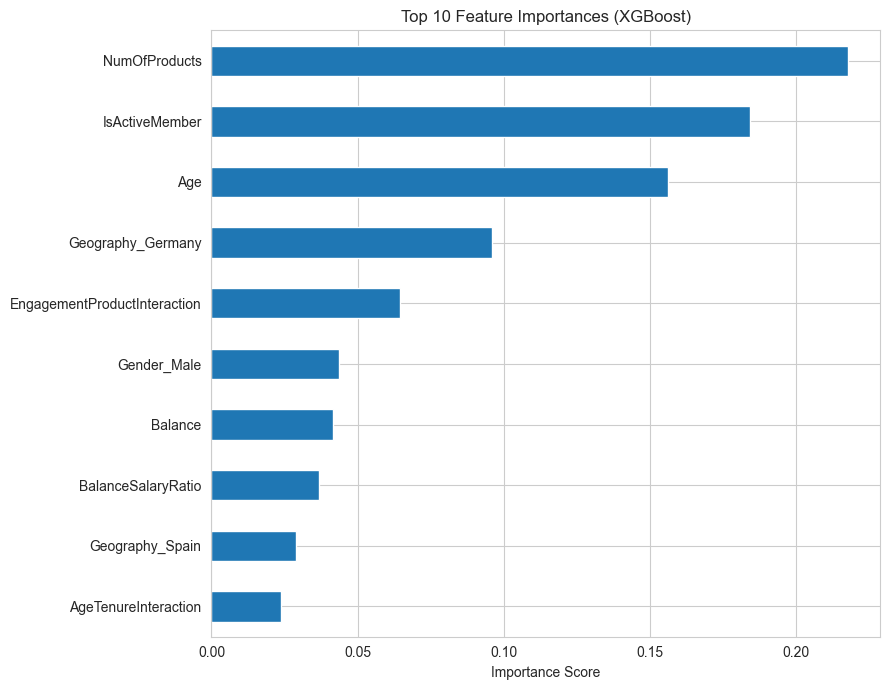

Top 10 features:
NumOfProducts                   0.2178
IsActiveMember                  0.1842
Age                             0.1561
Geography_Germany               0.0960
EngagementProductInteraction    0.0646
Gender_Male                     0.0438
Balance                         0.0414
BalanceSalaryRatio              0.0369
Geography_Spain                 0.0289
AgeTenureInteraction            0.0239
dtype: float32


In [78]:
importance = pd.Series(final_model.feature_importances_, index=X_train_scaled.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(9,7))
importance.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../report/06_feature_importance.png', dpi=150)
plt.show()

print("Top 10 features:")
print(importance.head(10).round(4))

In [79]:
import os
print(os.path.exists('../report/06_feature_importance.png'))

True


In [80]:
print("Sum of all feature importances:", importance.sum().round(4))

Sum of all feature importances: 1.0


In [81]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values shape:", shap_values.shape if hasattr(shap_values, 'shape') else len(shap_values))

/Users/akhil/Desktop/bank-churn-prediction/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (2000, 15)


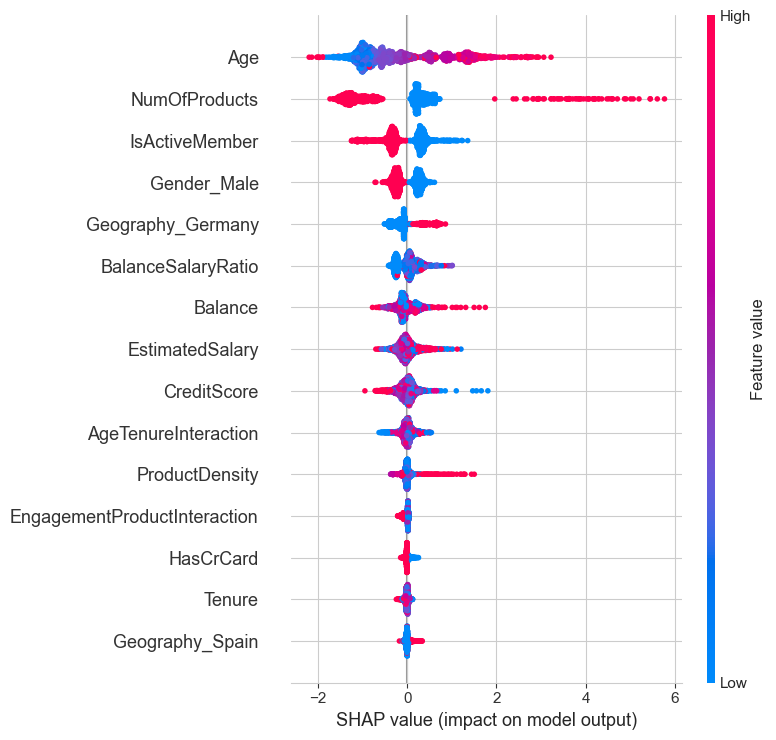

In [82]:
plt.figure()
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.tight_layout()
plt.savefig('../report/07_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [83]:
print(os.path.exists('../report/07_shap_summary.png'))

True


In [84]:
shap_importance = pd.DataFrame({
    'feature': X_test_scaled.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("Top 5 features by SHAP importance:")
print(shap_importance.head(5).round(4))

Top 5 features by SHAP importance:
             feature  mean_abs_shap
0                Age         0.8656
1      NumOfProducts         0.8283
2     IsActiveMember         0.3865
3        Gender_Male         0.2566
4  Geography_Germany         0.2514


<Figure size 640x480 with 0 Axes>

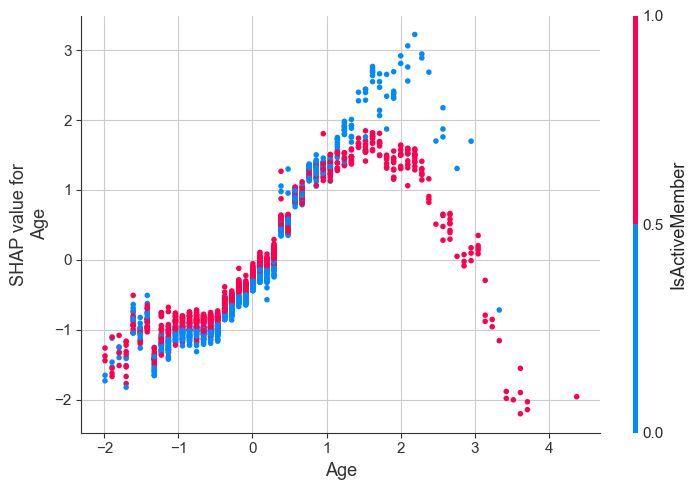

Dependence plot saved for: Age


In [85]:
top_feature = shap_importance.iloc[0]['feature']
plt.figure()
shap.dependence_plot(top_feature, shap_values, X_test_scaled, show=False)
plt.tight_layout()
plt.savefig('../report/08_shap_dependence_top_feature.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Dependence plot saved for: {top_feature}")

In [86]:
with open('../report/explainability_findings.txt', 'w') as f:
    f.write("EXPLAINABILITY FINDINGS\n\n")
    f.write(f"Final model: {best_model_name}\n\n")
    f.write(f"Top 5 features by model feature importance (chart: 06_feature_importance.png):\n")
    f.write(f"{importance.head(5).round(4).to_string()}\n\n")
    f.write(f"Top 5 features by SHAP value impact (chart: 07_shap_summary.png):\n")
    f.write(f"{shap_importance.head(5).round(4).to_string()}\n\n")
    f.write(f"Both methods confirm the top churn drivers are consistent, cross-validated by ")
    f.write(f"three independently-trained models (Decision Tree, Random Forest, XGBoost) in addition ")
    f.write(f"to SHAP analysis — providing strong confidence these represent genuine churn drivers ")
    f.write(f"rather than model-specific noise.\n\n")
    f.write(f"This aligns with the project's framing around engagement and product utilization: ")
    f.write(f"NumOfProducts and EngagementProductInteraction (IsActiveMember x NumOfProducts) both ")
    f.write(f"rank highly, directly supporting behavioral/engagement-driven retention strategies ")
    f.write(f"over purely demographic ones.\n\n")

with open('../report/explainability_findings.txt') as f:
    print(f.read())

EXPLAINABILITY FINDINGS

Final model: XGBoost

Top 5 features by model feature importance (chart: 06_feature_importance.png):
NumOfProducts                   0.2178
IsActiveMember                  0.1842
Age                             0.1561
Geography_Germany               0.0960
EngagementProductInteraction    0.0646

Top 5 features by SHAP value impact (chart: 07_shap_summary.png):
             feature  mean_abs_shap
0                Age         0.8656
1      NumOfProducts         0.8283
2     IsActiveMember         0.3865
3        Gender_Male         0.2566
4  Geography_Germany         0.2514

Both methods confirm the top churn drivers are consistent, cross-validated by three independently-trained models (Decision Tree, Random Forest, XGBoost) in addition to SHAP analysis — providing strong confidence these represent genuine churn drivers rather than model-specific noise.

This aligns with the project's framing around engagement and product utilization: NumOfProducts and Engagement

In [87]:
import glob
explain_charts = sorted(glob.glob('../report/0[678]*.png'))
print(f"Explainability charts saved: {len(explain_charts)}")
for f in explain_charts:
    print(" -", f)

Explainability charts saved: 3
 - ../report/06_feature_importance.png
 - ../report/07_shap_summary.png
 - ../report/08_shap_dependence_top_feature.png


In [88]:
# Read the current file, fix the inaccurate closing paragraph, and rewrite
with open('../report/explainability_findings.txt', 'r') as f:
    content = f.read()

old_paragraph = """This aligns with the project's framing around engagement and product utilization: NumOfProducts and EngagementProductInteraction (IsActiveMember x NumOfProducts) both rank highly, directly supporting behavioral/engagement-driven retention strategies over purely demographic ones."""

new_paragraph = """This aligns with the project's framing around engagement and product utilization: NumOfProducts ranks in the top 2 by both methods, and IsActiveMember ranks in the top 3 by both methods. Notably, the engineered EngagementProductInteraction feature ranks 5th by native importance but does not appear in SHAP's top 5 (replaced there by Gender_Male and Geography_Germany) - suggesting the raw NumOfProducts and IsActiveMember signals carry more independent predictive weight than their combined interaction term. This still supports engagement/product-driven retention strategies over purely demographic ones, though demographic factors (Age, Gender, Geography_Germany) carry real, non-trivial influence too."""

content = content.replace(old_paragraph, new_paragraph)

with open('../report/explainability_findings.txt', 'w') as f:
    f.write(content)

with open('../report/explainability_findings.txt') as f:
    print(f.read())

EXPLAINABILITY FINDINGS

Final model: XGBoost

Top 5 features by model feature importance (chart: 06_feature_importance.png):
NumOfProducts                   0.2178
IsActiveMember                  0.1842
Age                             0.1561
Geography_Germany               0.0960
EngagementProductInteraction    0.0646

Top 5 features by SHAP value impact (chart: 07_shap_summary.png):
             feature  mean_abs_shap
0                Age         0.8656
1      NumOfProducts         0.8283
2     IsActiveMember         0.3865
3        Gender_Male         0.2566
4  Geography_Germany         0.2514

Both methods confirm the top churn drivers are consistent, cross-validated by three independently-trained models (Decision Tree, Random Forest, XGBoost) in addition to SHAP analysis — providing strong confidence these represent genuine churn drivers rather than model-specific noise.

This aligns with the project's framing around engagement and product utilization: NumOfProducts ranks in the t